# CNN, Hybrid & Stacked Model

Trains and compares four model tiers:
- **Logistic Regression**: distance + angle only (fixed baseline)
- **XGBoost**: all tabular features
- **XGNet**: CNN on freeze-frame heatmaps only (3 × 68 × 52)
- **HybridXGNet**: CNN branch + tabular MLP branch, combined classifier
- **Stacked**: XGNet as feature extractor → 64-dim embedding fed into XGBoost

All models evaluated on the **validation set**. Test set is reserved for final evaluation.

## 1. Load Data

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_auc_score, brier_score_loss

from data import load_features, split_data
from models import (
    train_baseline, train_xgboost,
    train_cnn, train_hybrid_cnn,
    make_X_tabular
)
from models.stacked_training import train_stacked_model, extract_embeddings

features_df = load_features()
train, val, test = split_data(features_df)

print(f"Train: {len(train)} shots | {train['is_goal'].mean():.1%} goals")
print(f"Val:   {len(val)} shots | {val['is_goal'].mean():.1%} goals")
print(f"Test:  {len(test)} shots | {test['is_goal'].mean():.1%} goals")
if torch.cuda.is_available():
    torch.device("cuda")
print(f"\nDevice: {'cuda' if torch.cuda.is_available() else 'cpu'}")

2026-07-18 20:27:47,248 - data - INFO - Found 35 valid competitions.
Loading statsbomb API...
Building features...
Dropped 848 shots without freeze frame
Train: 42051 | Val: 9113 | Test: 8990
Train: 42051 shots | 10.0% goals
Val:   9113 shots | 10.1% goals
Test:  8990 shots | 10.3% goals

Device: cuda


## 2. Verify Heatmap Input Shape

In [2]:
# Confirm input shape matches CNN architecture: (3, 68, 52)
sample = np.stack(train['heatmap'].values)
print(f"Heatmap batch shape: {sample.shape}")
print(f"Expected:            (n, 3, 68, 52)")
assert sample.shape[1:] == (3, 68, 52), "❌ Unexpected heatmap shape!"
print("✅ Shape confirmed")

Heatmap batch shape: (42051, 3, 68, 52)
Expected:            (n, 3, 68, 52)
✅ Shape confirmed


## 3. Train XGNet (Heatmap only)

In [3]:
print("Training XGNet (heatmap only)...")
model_cnn, train_losses_cnn, val_losses_cnn = train_cnn(train, val, epochs=50, batch_size=64, lr=0.0005, weight_decay=1e-4)

Training XGNet (heatmap only)...
Epoch   5 | Train Loss: 0.5523 | Val Loss: 0.5541 | LR: 0.000500
Epoch  10 | Train Loss: 0.5396 | Val Loss: 0.5432 | LR: 0.000500
Epoch  15 | Train Loss: 0.5193 | Val Loss: 0.5404 | LR: 0.000250
Epoch  20 | Train Loss: 0.5004 | Val Loss: 0.5419 | LR: 0.000125
--> Early Stopping in Epoche 24. Best Val Loss: 0.5393


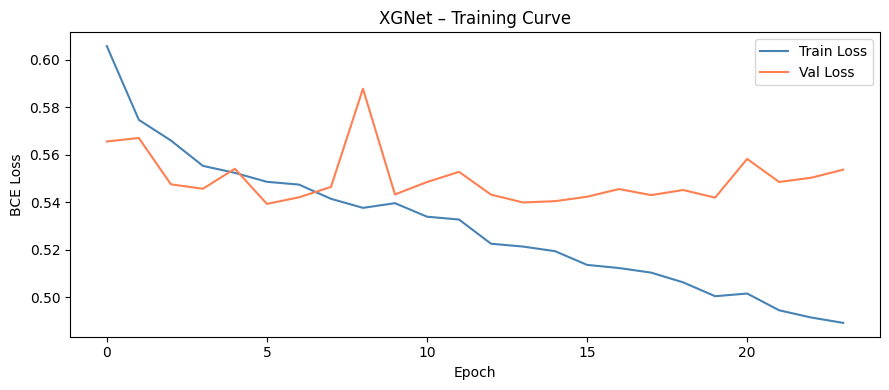

In [4]:
# Training curve — check for overfitting
# Ideal: both curves decrease and converge
# Red flag: val loss increases while train keeps dropping
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses_cnn, label='Train Loss', color='steelblue')
ax.plot(val_losses_cnn,   label='Val Loss',   color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('XGNet – Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Evaluate XGNet on val set
# BCEWithLogitsLoss has no Sigmoid → apply manually at inference
X_val_heatmap = torch.tensor(np.stack(val['heatmap'].values), dtype=torch.float32)
y_val = val['is_goal'].values

model_cnn.eval()
with torch.no_grad():
    y_proba_cnn = torch.sigmoid(model_cnn(X_val_heatmap)).numpy()

auc_cnn   = roc_auc_score(y_val, y_proba_cnn)
brier_cnn = brier_score_loss(y_val, y_proba_cnn)
print(f"XGNet (heatmap only) →  AUC: {auc_cnn:.3f}  |  Brier: {brier_cnn:.4f}")

XGNet (heatmap only) →  AUC: 0.800  |  Brier: 0.0974


## 4. Train HybridXGNet (CNN + Tabular)

In [6]:
print("Training HybridXGNet (CNN + tabular)...")
model_hybrid, train_losses_hybrid, val_losses_hybrid, preprocessor = train_hybrid_cnn(train, val, epochs=50, batch_size=64, lr=0.0005, weight_decay=1e-4, y_cols_to_flip=[])

Training HybridXGNet (CNN + tabular)...
Epoch   5 | Train Loss: 0.5469 | Val Loss: 0.5417 | LR: 0.000500
Epoch  10 | Train Loss: 0.5379 | Val Loss: 0.5382 | LR: 0.000500
Epoch  15 | Train Loss: 0.5262 | Val Loss: 0.5331 | LR: 0.000500
Epoch  20 | Train Loss: 0.5015 | Val Loss: 0.5389 | LR: 0.000250
Epoch  25 | Train Loss: 0.4723 | Val Loss: 0.5647 | LR: 0.000125
--> Early Stopping in Epoche 29. Best Val Loss: 0.5328


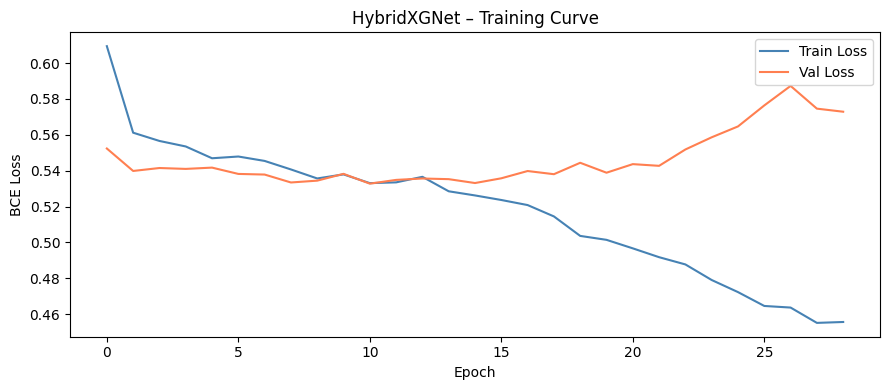

In [7]:
# Training curve for Hybrid model
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses_hybrid, label='Train Loss', color='steelblue')
ax.plot(val_losses_hybrid,   label='Val Loss',   color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('HybridXGNet – Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
X_val_tab = preprocessor.fit_transform(make_X_tabular(train))  # fit on train
X_val_tab = preprocessor.transform(make_X_tabular(val))        # transform val

if hasattr(X_val_tab, 'toarray'):
    X_val_tab = X_val_tab.toarray()

X_val_tab_t = torch.tensor(X_val_tab, dtype=torch.float32)

model_hybrid.eval()
with torch.no_grad():
    y_proba_hybrid = torch.sigmoid(model_hybrid(X_val_heatmap, X_val_tab_t)).numpy()

auc_hybrid   = roc_auc_score(y_val, y_proba_hybrid)
brier_hybrid = brier_score_loss(y_val, y_proba_hybrid)
print(f"HybridXGNet (CNN + tabular) →  AUC: {auc_hybrid:.3f}  |  Brier: {brier_hybrid:.4f}")

HybridXGNet (CNN + tabular) →  AUC: 0.806  |  Brier: 0.0914


## 5. Stacked Model (XGNet → XGBoost)

Uses the trained XGNet as a **feature extractor**: the final classification layer is removed,
yielding a 64-dimensional spatial embedding per shot. These embeddings are concatenated
with tabular features and fed into XGBoost for the final prediction.

This combines the spatial reasoning of a CNN with the robustness of gradient boosting.

In [9]:
# Stage 1: use trained XGNet as CNN feature extractor (64-dim embedding)
# Stage 2: XGBoost on CNN embeddings + tabular features
print('Training Stacked model (XGNet → XGBoost)...')
model_stacked, embedder, prep_stacked = train_stacked_model(train, val, model_cnn)
print('✅ Stacking complete')

Training Stacked model (XGNet → XGBoost)...
✅ Stacking complete


In [10]:
# Evaluate stacked model on val set
val_emb = extract_embeddings(embedder, val)
val_tab_stacked = prep_stacked.transform(make_X_tabular(val))
if hasattr(val_tab_stacked, 'toarray'):
    val_tab_stacked = val_tab_stacked.toarray()

X_val_stacked   = np.hstack([val_emb, val_tab_stacked])
y_proba_stacked = model_stacked.predict_proba(X_val_stacked)[:, 1]

auc_stacked   = roc_auc_score(y_val, y_proba_stacked)
brier_stacked = brier_score_loss(y_val, y_proba_stacked)
print(f'Stacked (XGNet → XGBoost) →  AUC: {auc_stacked:.3f}  |  Brier: {brier_stacked:.4f}')

Stacked (XGNet → XGBoost) →  AUC: 0.803  |  Brier: 0.0932


## 6. Full Model Comparison

In [11]:
# Train baselines for comparison
model_lr  = train_baseline(train)
model_xgb = train_xgboost(train)

X_val_lr  = val[['distance', 'angle']].values
X_val_xgb = make_X_tabular(val)

auc_lr    = roc_auc_score(y_val, model_lr.predict_proba(X_val_lr)[:, 1])
brier_lr  = brier_score_loss(y_val, model_lr.predict_proba(X_val_lr)[:, 1])

auc_xgb   = roc_auc_score(y_val, model_xgb.predict_proba(X_val_xgb)[:, 1])
brier_xgb = brier_score_loss(y_val, model_xgb.predict_proba(X_val_xgb)[:, 1])

# StatsBomb reference
sb_xg    = val['statsbomb_xg'].values
mask     = ~np.isnan(sb_xg)
auc_sb   = roc_auc_score(y_val[mask], sb_xg[mask])
brier_sb = brier_score_loss(y_val[mask], sb_xg[mask])

# Summary table — stacked added
results = [
    ('Logistic Regression',        auc_lr,      brier_lr),
    ('XGBoost',                    auc_xgb,     brier_xgb),
    ('XGNet (heatmap only)',        auc_cnn,     brier_cnn),
    ('HybridXGNet (CNN + tabular)', auc_hybrid,  brier_hybrid),
    ('Stacked (XGNet → XGBoost)',   auc_stacked, brier_stacked),
    ('StatsBomb xG (reference)',    auc_sb,      brier_sb),
]

print(f"{'Model':<32} {'AUC':>6}  {'Brier':>7}")
print("-" * 50)
for i, (name, auc, brier) in enumerate(results):
    if i == len(results) - 1:
        print("-" * 50)
    print(f"{name:<32} {auc:>6.3f}  {brier:>7.4f}")

Model                               AUC    Brier
--------------------------------------------------
Logistic Regression               0.745   0.0839
XGBoost                           0.794   0.0803
XGNet (heatmap only)              0.800   0.0974
HybridXGNet (CNN + tabular)       0.806   0.0914
Stacked (XGNet → XGBoost)         0.803   0.0932
--------------------------------------------------
StatsBomb xG (reference)          0.810   0.0746


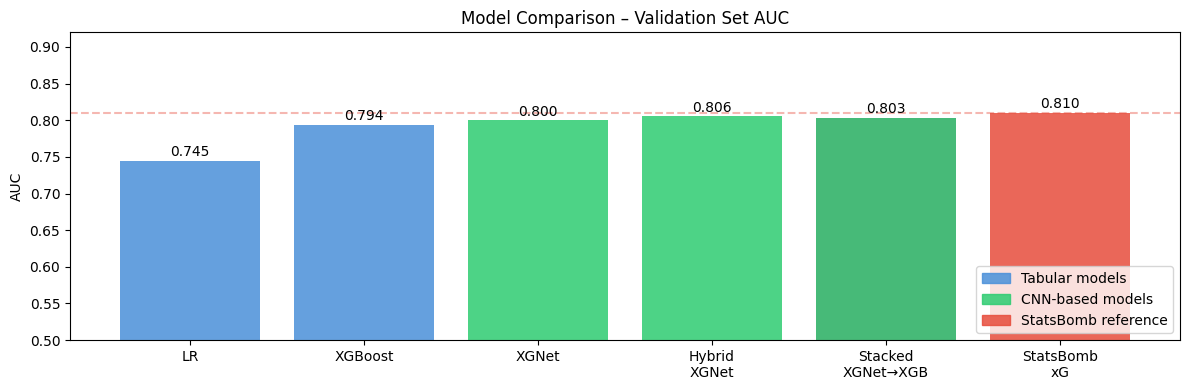

In [12]:
# Visual AUC comparison across all models
# Blue  = tabular/baseline models
# Green = CNN-based models
# Red   = StatsBomb reference
names  = ['LR', 'XGBoost', 'XGNet', 'Hybrid\nXGNet', 'Stacked\nXGNet→XGB', 'StatsBomb\nxG']
aucs   = [r[1] for r in results]
colors = ['#4a90d9', '#4a90d9', '#2ecc71', '#2ecc71', '#27ae60', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(names, aucs, color=colors, alpha=0.85)
ax.set_ylim(0.5, 0.92)
ax.set_ylabel('AUC')
ax.set_title('Model Comparison – Validation Set AUC')
ax.axhline(auc_sb, color='#e74c3c', linestyle='--', alpha=0.4, label='StatsBomb reference')

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=10)

from matplotlib.patches import Patch
legend = [
    Patch(color='#4a90d9', alpha=0.85, label='Tabular models'),
    Patch(color='#2ecc71', alpha=0.85, label='CNN-based models'),
    Patch(color='#e74c3c', alpha=0.85, label='StatsBomb reference'),
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

## 7. Training Curve Comparison

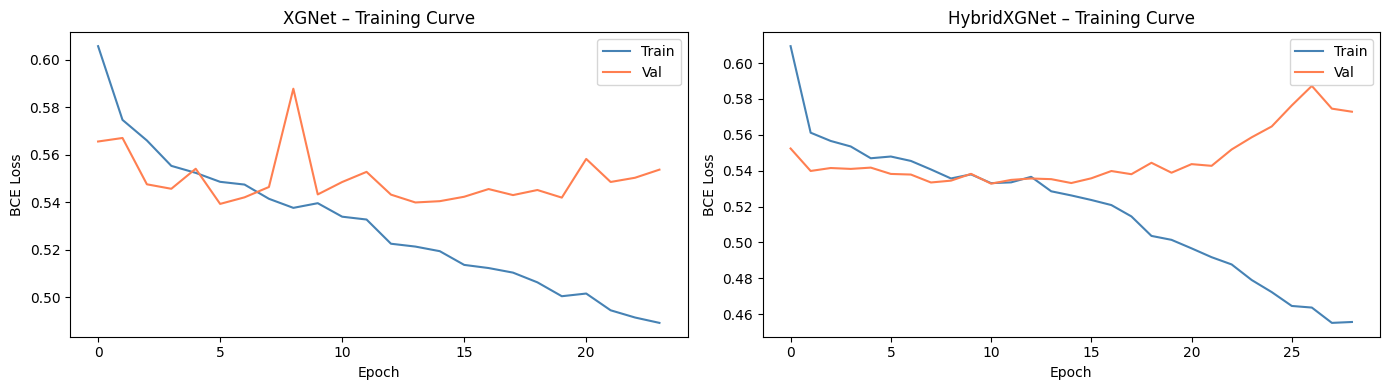

In [13]:
# Side-by-side training curves for XGNet vs HybridXGNet
# Useful to spot if one overfits more than the other
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, train_l, val_l, title in [
    (axes[0], train_losses_cnn,    val_losses_cnn,    'XGNet'),
    (axes[1], train_losses_hybrid, val_losses_hybrid, 'HybridXGNet'),
]:
    ax.plot(train_l, label='Train', color='steelblue')
    ax.plot(val_l,   label='Val',   color='coral')
    ax.set_title(f'{title} – Training Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## 8. xG Distribution – HybridXGNet vs. Ground Truth

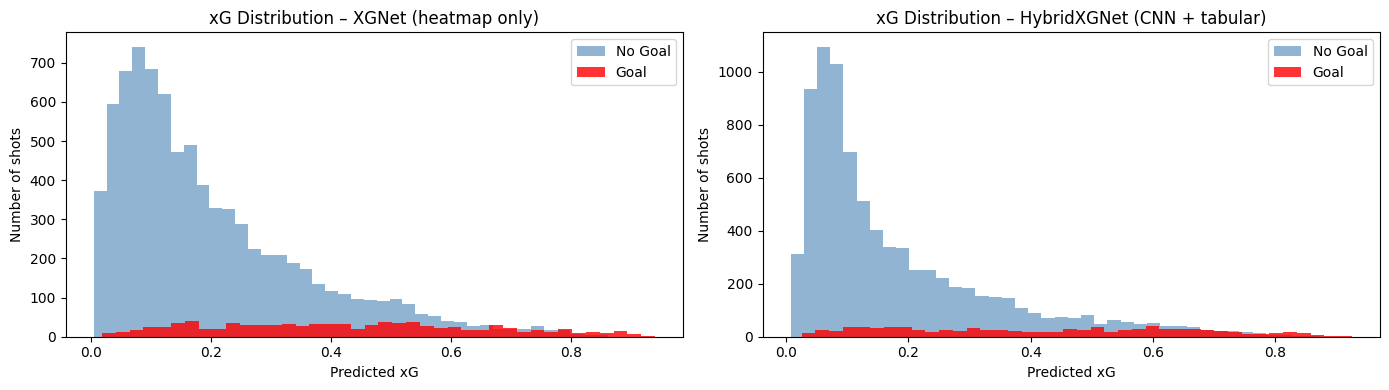

In [14]:
# Goals should cluster toward higher predicted xG values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, y_proba, title in [
    (axes[0], y_proba_cnn,    'XGNet (heatmap only)'),
    (axes[1], y_proba_hybrid, 'HybridXGNet (CNN + tabular)'),
]:
    ax.hist(y_proba[y_val == 0], bins=40, alpha=0.6, label='No Goal', color='steelblue')
    ax.hist(y_proba[y_val == 1], bins=40, alpha=0.8, label='Goal',    color='red')
    ax.set_xlabel('Predicted xG')
    ax.set_ylabel('Number of shots')
    ax.set_title(f'xG Distribution – {title}')
    ax.legend()

plt.tight_layout()
plt.show()